# **Analyse de la Fidélisation Client (Churn)**
#### Banque $\cdot$ Finance $\cdot$ Marketing

### Contexte du Projet
Dans un secteur bancaire de plus en plus concurrentiel, la rétention des clients est devenue un levier stratégique majeur pour la croissance et la pérennité des institutions financières. Pour la **ABC Multinational Bank**, l'enjeu est de taille : il est statistiquement prouvé qu'acquérir un nouveau client coûte nettement plus cher que d'en conserver un existant.[1](#ref1)

Face à ce défi, la banque souhaite passer d'une stratégie réactive à une **stratégie proactive** en identifiant les signes précurseurs d'un départ client (le "churn").

### Objectif de l'Étude
L'objectif principal de ce projet est de développer un modèle prédictif capable d'anticiper le départ des clients. En s'appuyant sur les données historiques des titulaires de comptes, nous cherchons à répondre à la question suivante :
> *"Quels sont les facteurs déterminants qui poussent un client à quitter l'établissement, et pouvons-nous prédire ce comportement avec précision ?"*

#### **Dictionnaire de données**

Colonnes :

* **customer_id** → Identifiant unique du client (Numéro de compte)
* **credit_score** → Score de crédit du client
* **country** → Pays de résidence
* **gender** → Sexe du client
* **age** → Âge du client
* **tenure** → Nombre d'années depuis lesquelles le client est chez ABC Bank
* **balance** → Solde actuel du compte bancaire
* **products_number** → Nombre de produits bancaires détenus par le client
* **credit_card** → Indique si le client possède une carte de crédit (1 = Oui, 0 = Non)
* **active_member** → Indique si le client est considéré comme un membre actif (1 = Oui, 0 = Non)
* **estimated_salary** → Salaire annuel estimé du client
* **churn** → Variable cible : 1 si le client a quitté la banque, 0 s'il est resté.

## **1. Imports & Configuration**

---



In [ ]:
# Installation
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
! pip install fastapi
! pip install nest_asyncio
# Installation
!pip install pyngrok -q
# Installation
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 72.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 64.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 90.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 75.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 17.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
   ━━━━━━━━━━━━━

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn — prétraitement
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline


# Sklearn — modèles
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Sklearn — évaluation
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)


from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
import joblib
import nest_asyncio
import uvicorn
import threading

## **2. Chargements des données**

---

In [12]:
# Chargement des données
data = pd.read_csv("/workspaces/Bank-Customer-Churn-Prediction/data/Bank Customer Churn Prediction.csv", sep = ',')

In [13]:
# Affichons nos données (les 5 premières et les 5 dernières lignes)
data

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## **3. Analyse exploratoire des données (AED)**

---

### **3.1. Inspection basique**

In [14]:
# Infos générales de notre dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


Notre dataset est constitué de 10.000 lignes ***(nombre de clients)*** et 12 colonnes ***(caractéristiques de chaque client)***.
On constate que nous n'avons pas de valeurs manquantes et cela pour chacun des 10.000 clients de notre banque. **Nos données sont de 3 types : float64, int64 et object.**

In [15]:
# Description et stats de base
data.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
credit_score,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
products_number,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
credit_card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
active_member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48
churn,10000.0,2.037000e-01,0.402769,0.00,0.00,0.000000e+00,0.000000e+00,1.00


### **3.2. Distribution de la variable cible**

**Taux de Désabonnement (Churn)**: La moyenne de la colonne churn est de **0.2037**, ce qui signifie qu'environ **20.37% des clients** ont quitté la banque. On peut visualiser cette information via l'histogramme ci-dessous :

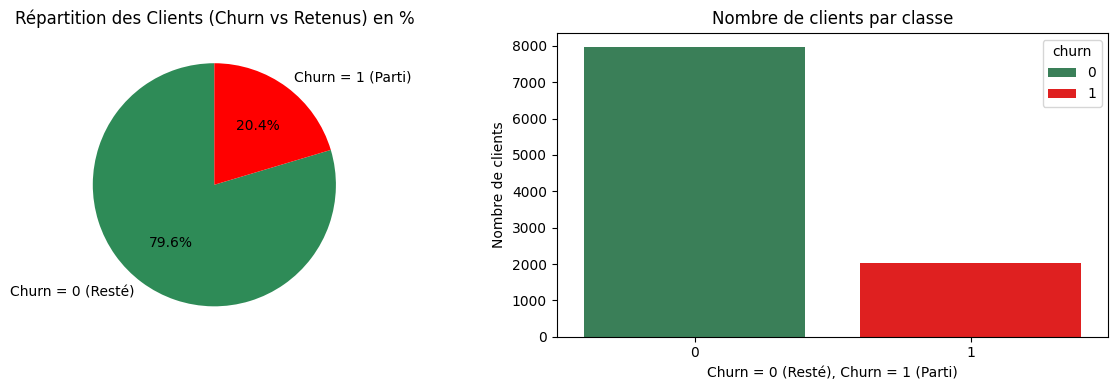

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# diagramme circulaire

axes[0].pie(
        data['churn'].value_counts(),
        labels=['Churn = 0 (Resté)', 'Churn = 1 (Parti)'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['seagreen', 'red']
        )
axes[0].set_title('Répartition des Clients (Churn vs Retenus) en %')

# histogramme
sns.countplot(data=data, x='churn', hue='churn', palette=['seagreen', 'red'], ax=axes[1], )
axes[1].set_title('Nombre de clients par classe')
axes[1].set_xlabel('Churn = 0 (Resté), Churn = 1 (Parti)')
axes[1].set_ylabel('Nombre de clients')

plt.tight_layout()
plt.show()

Les premèires informations clés :

*  **Âge** : L'âge moyen des clients est d'environ **38.9 ans**, avec une fourchette allant de 18 à 92 ans.
*  **Score de Crédit** : Le score de crédit moyen est de **650.5**, variant de 350 à 850.
*  **Solde (Balance)** : Un quart des clients (25%) a un solde de 0.00, ce qui représente une part assez importante. Le solde moyen est d'environ **76.485,89 €**.
*  **Ancienneté (Tenure)** : L'ancienneté moyenne des clients est de **5 ans**, allant de 0 à 10 ans.
*  **Nombre de Produits** : Les clients détiennent en moyenne **1.53 produits**, avec un maximum de 4 produits.
*  **Salaires Estimés** : Les salaires annuels estimés varient considérablement, avec une moyenne d'environ **100.090,24 €**.

*La monnaie est l'Euro (€) car les 3 pays des clients sont dans la zone Euro.*

In [17]:
# Pays des clients
data['country'].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

### **3.3. Variables numériques**

In [18]:
# On va se concentrer sur les colonnes numériques utiles
col_num_u = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

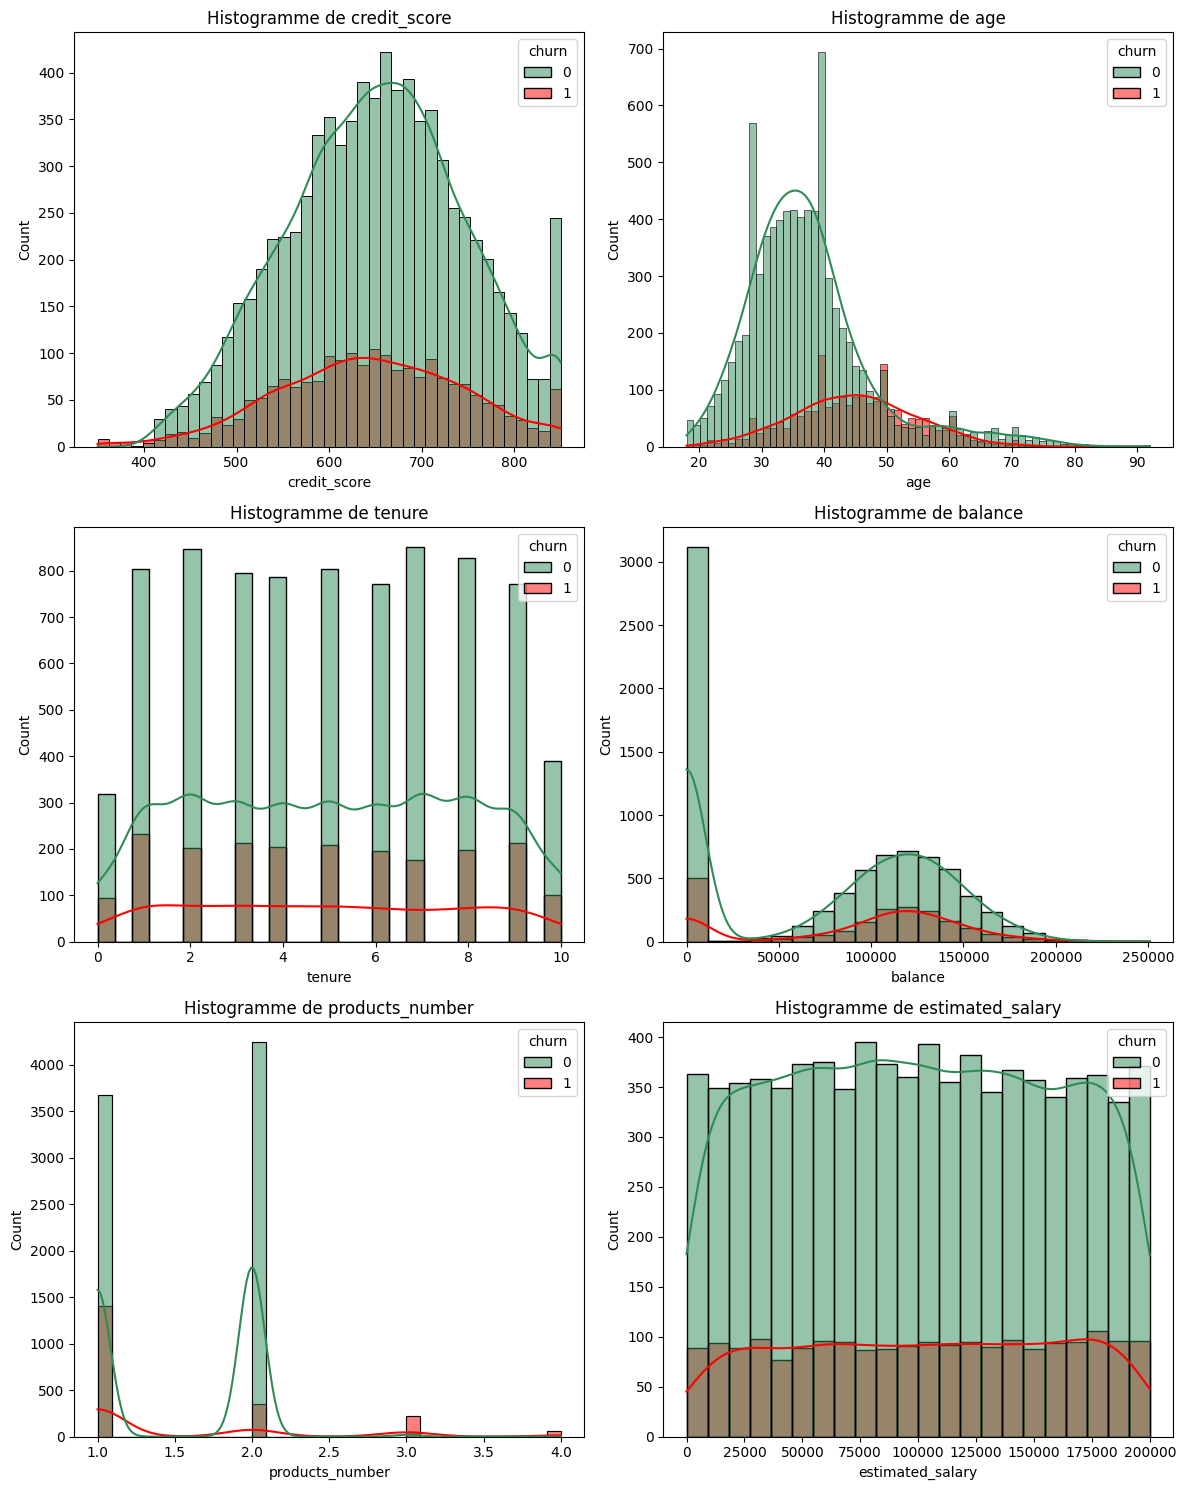

In [19]:
fig, axes = plt.subplots(3,2, figsize=(12, 15))

for i in range(len(col_num_u)):
    sns.histplot(data=data, x=col_num_u[i], ax=axes[i//2, i%2], hue='churn', palette=['seagreen', 'red'], kde=True)
    axes[i//2, i%2].set_title(f'Histogramme de {col_num_u[i]}')

plt.tight_layout()
plt.show()

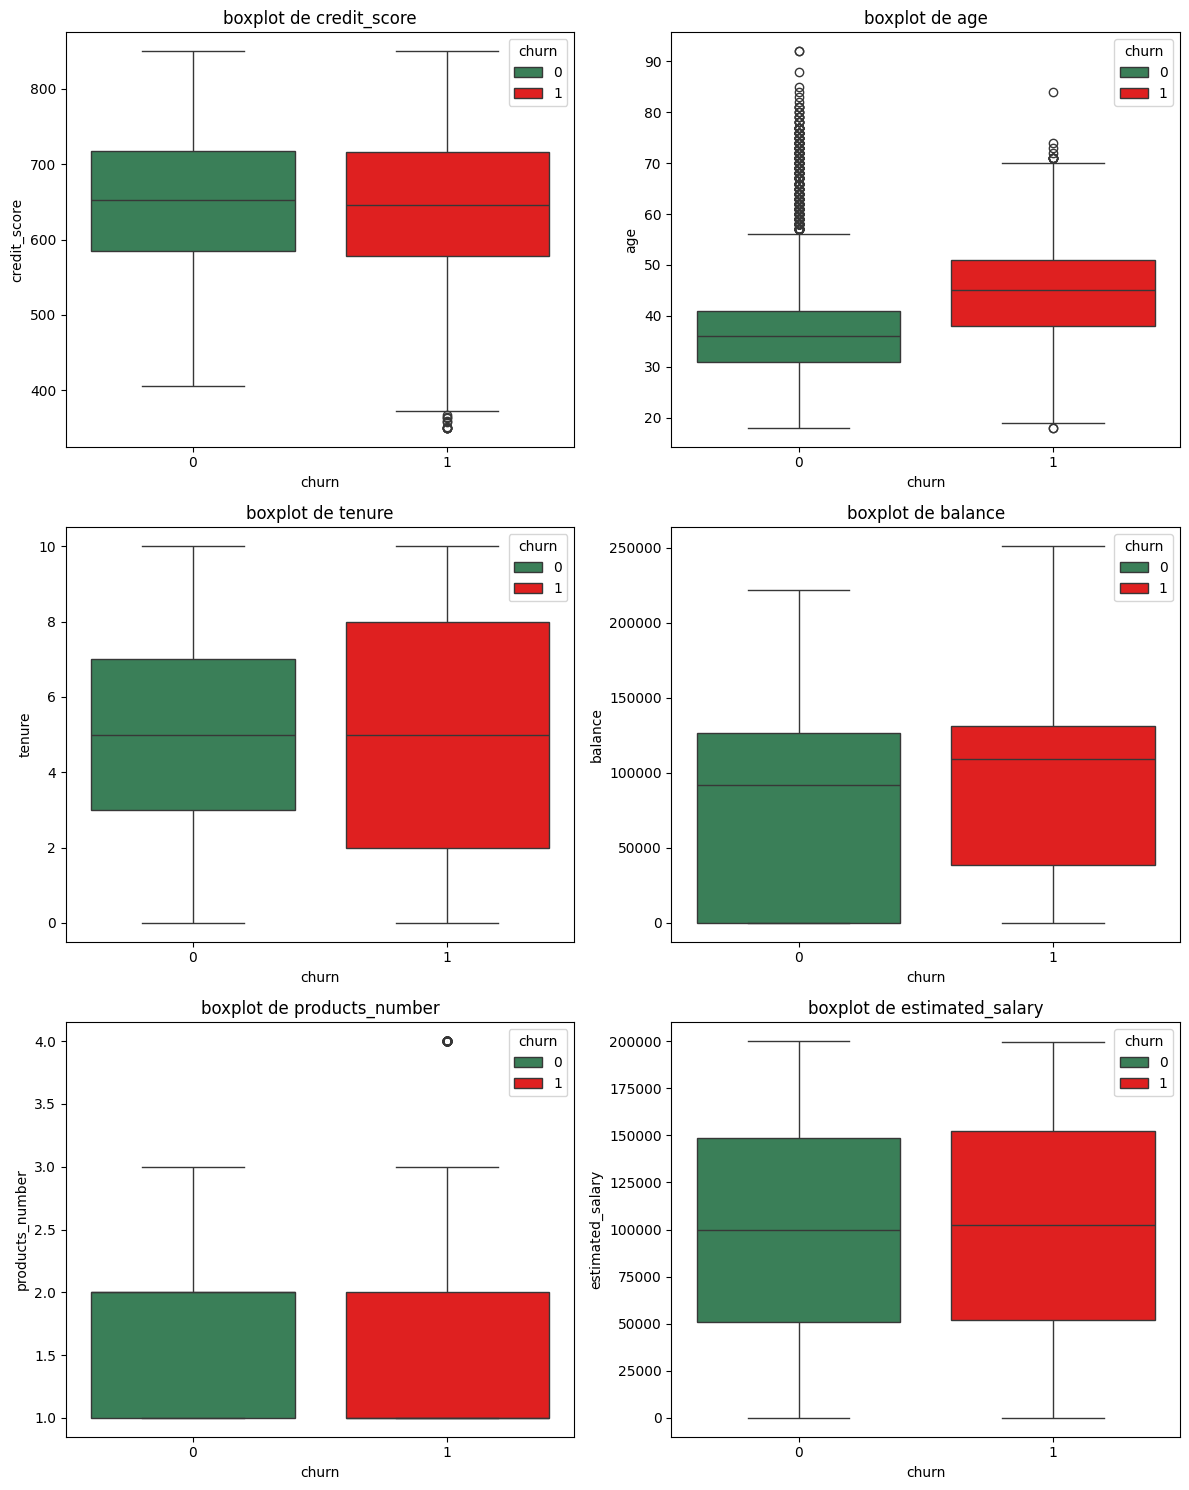

In [20]:
fig, axes = plt.subplots(3,2, figsize=(12, 15))

for i in range(len(col_num_u)):
    sns.boxplot(data=data, x='churn', y=col_num_u[i], ax=axes[i//2, i%2], palette=['seagreen', 'red'], hue='churn')
    axes[i//2, i%2].set_title(f'boxplot de {col_num_u[i]}')

plt.tight_layout()
plt.show()

L'analyse des graphiques (boxplot & histogramme) révèle que **l'âge** semble être le facteur le plus discriminant : **les clients qui partent (churn=1) sont nettement plus âgés (médiane autour de 45 ans) que ceux qui restent (médiane autour de 37 ans)**. On observe également qu'un **nombre élevé de produits (products_number > 2)** ou un **solde bancaire (balance) non nul** sont des indicateurs de risque de départ *(le solde est légèrement plus élevé chez les churners)*. En revanche, le salaire estimé et le score de crédit semblent avoir un impact négligeable sur la fidélisation.

### **3.4. Variables catégorielles**

In [21]:
# Variables catégorielles utiles
catego_col = ['country', 'gender', 'credit_card', 'active_member']

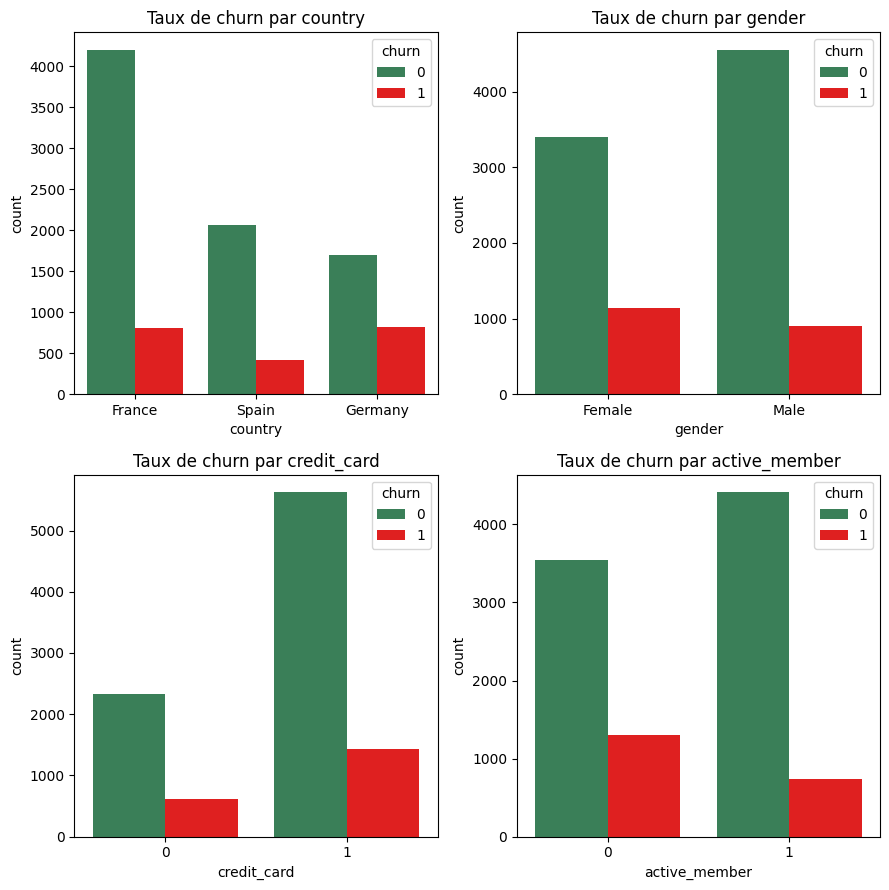

In [22]:
fig, ax = plt.subplots(2,2, figsize=(9, 9))

for i in range(len(catego_col)):
    sns.countplot(data=data, x=catego_col[i], hue='churn', palette=['seagreen', 'red'], ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(f'Taux de churn par {catego_col[i]}')


plt.tight_layout()
plt.show()

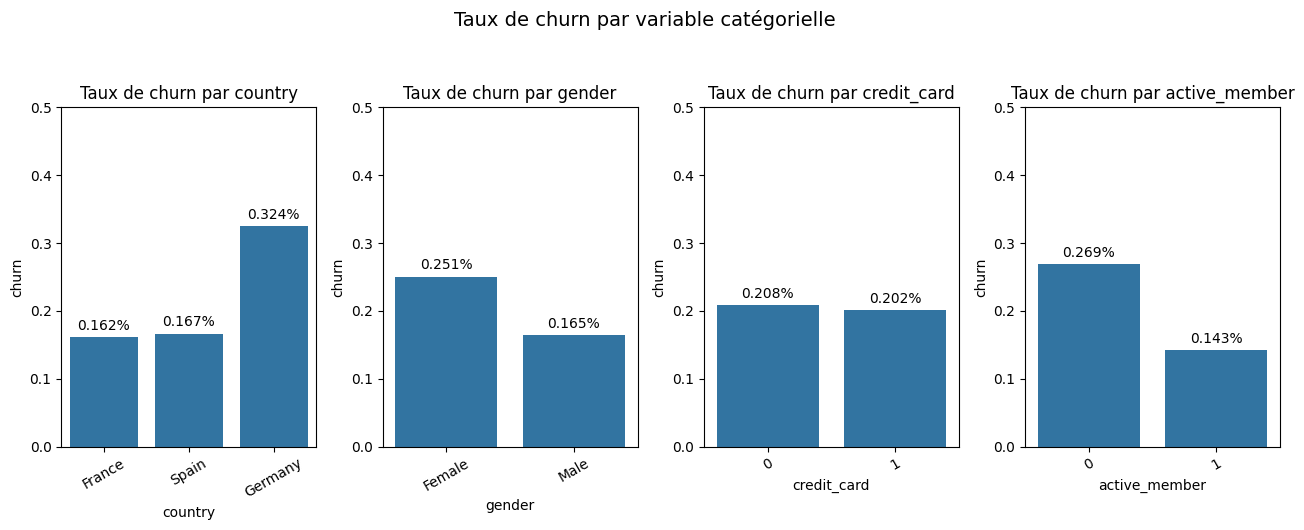

In [23]:
plt.figure(figsize=(13, 5))

for i, col in enumerate(catego_col):
    ax = plt.subplot(1, len(catego_col), i + 1)

    # sns.barplot calcule la moyenne (taux) automatiquement
    sns.barplot(data=data, x=col, y='churn', ax=ax, errorbar=None)

    # Ajout automatique des étiquettes de données
    ax.bar_label(ax.containers[0], fmt='%.3f%%', padding=3)

    ax.set_title(f'Taux de churn par {col}')
    ax.set_ylim(0, 0.5)
    plt.xticks(rotation=30)

plt.suptitle('Taux de churn par variable catégorielle', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

* **Pays (country) :** on constate que les clients en **Allemagne** ont plus tendance à churn que ceux de la France ou de l'Espagne. Ils ont le taux de désabonnement le plus élevé **(32%)**. Peut-être qu'ils sont plus exigeants ou que les services des deux autres pays sont meilleurs.

* **Sexe (gender) :** on constate que les femmes ont tendances à être moins fidèles que les hommes.

* **Carte de crédit (credit_card) :** La possession d'une carte de crédit ne semble pas avoir un impact majeur sur le taux de désabonnement, les taux étant très similaires pour les clients avec ou sans carte de crédit.

* **Membre actif (active_member) :** Les clients inactifs (active_member = 0) ont un taux de désabonnement nettement plus élevé **(environ 27%)** que les membres actifs **(environ 14%)**. C'est un indicateur clé, car l'engagement du client semble fortement lié à sa fidélité.

### **3.5. Matrix de corrélation**

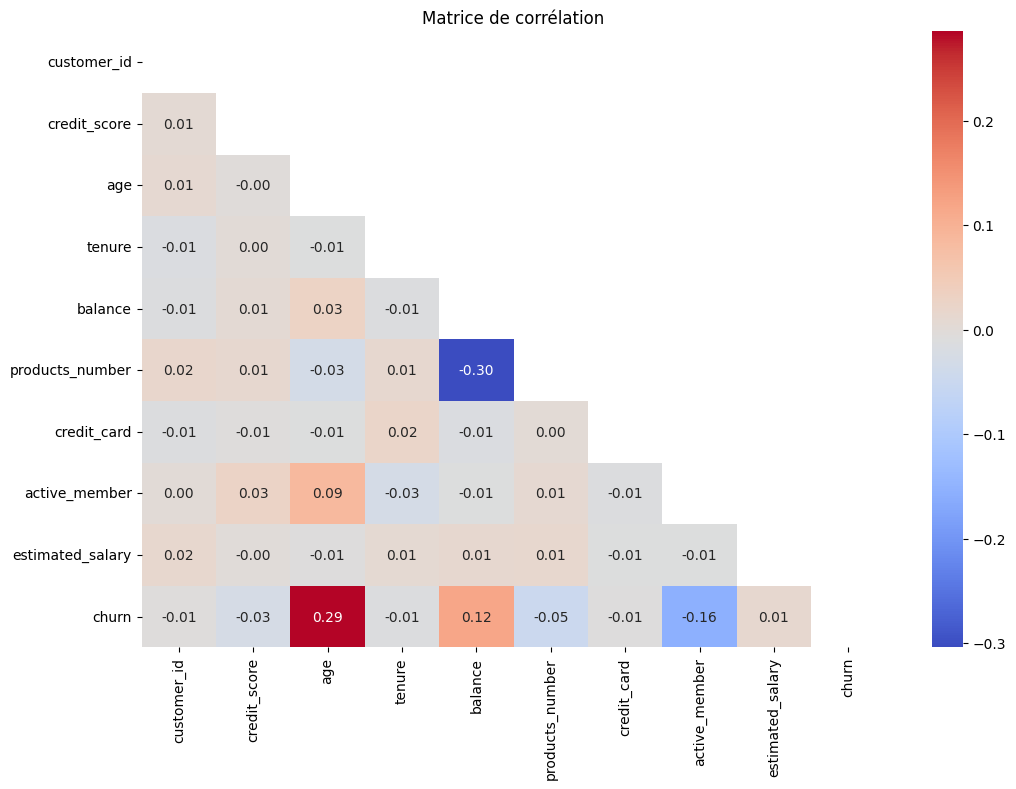

In [24]:
# Corrélation des variables numériques
plt.figure(figsize=(12, 8))

coef_corr = data.corr(numeric_only=True)

mask = np.triu(np.ones_like(coef_corr, dtype=bool)) # masquons la partie supérieure de la matrice

sns.heatmap(coef_corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de corrélation')
plt.show()

La matrice de corrélation confirme les tendances observées précédemment tout en précisant certaines relations entre les variables :

*   **L'âge est le principal moteur du churn** : Avec une corrélation positive de **0,29**, c'est la variable la plus liée au départ des clients. Cela confirme ce que nous avons observé avec les histogrammes et les boxplots.
*   **Engagement et fidélité** : On observe une corrélation négative de **-0,16** entre `active_member` et `churn`, confirmant que les membres actifs sont plus fidèles. De même, `balance` montre une légère corrélation positive (**0,12**) avec le churn.
*   **Relation produits/solde** : La corrélation négative la plus forte de la matrice (**-0,30**) se trouve entre `products_number` et `balance`, suggérant que les clients possédant plus de produits ont tendance à avoir des soldes moins élevés.
*   **Variables neutres** : Le salaire estimé, le score de crédit et la possession d'une carte de crédit n'ont quasiment aucune corrélation avec le churn (proche de **0**), ce qui signifie qu'ils ne sont pas de bons prédicteurs directs dans ce jeu de données.

## **4. Prétraitement des données**

---

In [25]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self):
        # On initialise les encodeurs pour les variables catégorielles
        self.encoder_gender = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        self.encoder_country = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

    def fit(self, X, y=None):
        # On ajuste les encodeurs sur les données (idéalement sur le train set)
        self.encoder_gender.fit(X[['gender']])
        self.encoder_country.fit(X[['country']])
        return self

    def transform(self, X):
        # On fait une copie pour éviter de modifier le DataFrame original en place
        X_clean = X.copy()

        # Suppression de l'identifiant s'il est présent
        if 'customer_id' in X_clean.columns:
            X_clean.drop(columns=['customer_id'], inplace=True)

        # Encodage des variables catégorielles
        X_clean['gender'] = self.encoder_gender.transform(X_clean[['gender']])
        X_clean['country'] = self.encoder_country.transform(X_clean[['country']])

        # Feature engineering : Ratio balance / salaire estimé (sécurisé contre la division par 0)
        X_clean['balance_salary_ratio'] = X_clean['balance'] / (X_clean['estimated_salary'] + 1e-8)

        # Création de l'étiquette solde nul
        X_clean['balance_a_zero'] = (X_clean['balance'] == 0).astype(int)

        return X_clean

In [26]:
# Pipeline
preprocessing_pipeline = Pipeline(steps=[
    ('feature_engineering', FeatureEngineering())
])

In [27]:
# Application sur le dataset
data_clean = preprocessing_pipeline.fit_transform(data)

In [28]:
# Affichage
print(data_clean.shape)
data_clean.head(10)

(10000, 13)


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,balance_salary_ratio,balance_a_zero
0,619,0.0,0.0,42,2,0.00,1,1,1,101348.88,1,0.000000,1
1,608,2.0,0.0,41,1,83807.86,1,0,1,112542.58,0,0.744677,0
2,502,0.0,0.0,42,8,159660.80,3,1,0,113931.57,1,1.401375,0
3,699,0.0,0.0,39,1,0.00,2,0,0,93826.63,0,0.000000,1
4,850,2.0,0.0,43,2,125510.82,1,1,1,79084.10,0,1.587055,0
5,645,2.0,1.0,44,8,113755.78,2,1,0,149756.71,1,0.759604,0
6,822,0.0,1.0,50,7,0.00,2,1,1,10062.80,0,0.000000,1
7,376,1.0,0.0,29,4,115046.74,4,1,0,119346.88,1,0.963969,0
8,501,0.0,1.0,44,4,142051.07,2,0,1,74940.50,0,1.895518,0
9,684,0.0,1.0,27,2,134603.88,1,1,1,71725.73,0,1.876647,0


## **5. Split Train / Test**

---

In [29]:
# Séparation terget et features
X = data_clean.drop(columns=['churn'])
y = data_clean['churn']

In [30]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8000, 12) (2000, 12) (8000,) (2000,)


## **6. Modélisation**

---

### **6.1 Fonction d'évaluation**

Pour l'évaluation de nos modèles, nous allons utiliser les métriques suivantes :

* **Accuracy** : La proportion de prédictions correctes parmi toutes les prédictions. Utile quand les classes sont équilibrées.
* **F1-Score** : La moyenne harmonique de la précision et du rappel. Très utile quand les classes sont déséquilibrées (ce qui est notre cas avec le churn).
* **ROC-AUC** : Mesure la capacité du modèle à distinguer les classes. Un score plus élevé indique une meilleure performance. Utile pour les problèmes de classification binaire.
* **Cross-Validation AUC (CV-AUC)** : Moyenne de l'AUC sur plusieurs plis de validation croisée, permettant une estimation plus robuste de la performance du modèle

In [32]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name="Model"):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps['model'], 'predict_proba'):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    cv = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc').mean()

    print(f"{'─'*50}")
    print(f"  {name}")
    print(f"  Accuracy : {acc:.4f}  |  F1 : {f1:.4f}  |  ROC-AUC : {auc:.4f}  |  CV-AUC : {cv:.4f}")
    return {'Model': name, 'Accuracy': acc, 'F1': f1, 'ROC-AUC': auc, 'CV-AUC': cv, 'object': pipeline}

In [33]:
# Créons une liste où on va stocker nos résultats d'évaluation
results = []

### **6.2 Baseline — Dummy Classifier**

In [34]:
dummy = DummyClassifier(strategy='most_frequent')
res_dummy = evaluate_model(dummy, X_train, X_test, y_train, y_test, name="Baseline Dummy (classe majoritaire)")
results.append(res_dummy)

──────────────────────────────────────────────────
  Baseline Dummy (classe majoritaire)
  Accuracy : 0.8035  |  F1 : 0.0000  |  ROC-AUC : 0.5000  |  CV-AUC : 0.5000


### **6.3 Régression Logistique**

In [35]:
Lr = LogisticRegression(random_state=42, max_iter=1000)
res_Lr = evaluate_model(Lr, X_train, X_test, y_train, y_test, name="Logistic Regression")
results.append(res_Lr)

──────────────────────────────────────────────────
  Logistic Regression
  Accuracy : 0.8150  |  F1 : 0.2802  |  ROC-AUC : 0.7645  |  CV-AUC : 0.7509


### **6.4 Arbre de Décision**

In [36]:
Dt = DecisionTreeClassifier(max_depth=6, random_state=42)
res_Dt = evaluate_model(Dt, X_train, X_test, y_train, y_test, name="Decision Tree")
results.append(res_Dt)

──────────────────────────────────────────────────
  Decision Tree
  Accuracy : 0.8525  |  F1 : 0.5059  |  ROC-AUC : 0.8145  |  CV-AUC : 0.8260


### **6.5 Random Forest**

In [37]:
Rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
res_Rf = evaluate_model(Rf, X_train, X_test, y_train, y_test, "Random Forest")
results.append(res_Rf)

──────────────────────────────────────────────────
  Random Forest
  Accuracy : 0.8725  |  F1 : 0.5867  |  ROC-AUC : 0.8564  |  CV-AUC : 0.8506


### **6.6 Gradient Boosting**

In [38]:
Gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
res_Gb = evaluate_model(Gb, X_train, X_test, y_train, y_test, "Gradient Boosting")
results.append(res_Gb)

──────────────────────────────────────────────────
  Gradient Boosting
  Accuracy : 0.8635  |  F1 : 0.5794  |  ROC-AUC : 0.8656  |  CV-AUC : 0.8585


## **7. Comparaison des modèles**

---

In [39]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'object'} for r in results])
results_df = results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(results_df.style.highlight_max(color='seagreen', subset=['Accuracy', 'F1', 'ROC-AUC', 'CV-AUC']))

,Model,Accuracy,F1,ROC-AUC,CV-AUC
0,Gradient Boosting,0.863500,0.579353,0.865598,0.858505
1,Random Forest,0.872500,0.586710,0.856359,0.850602
2,Decision Tree,0.852500,0.505863,0.814454,0.825994
3,Logistic Regression,0.815000,0.280156,0.764473,0.750855
4,Baseline Dummy (classe majoritaire),0.803500,0.000000,0.500000,0.500000


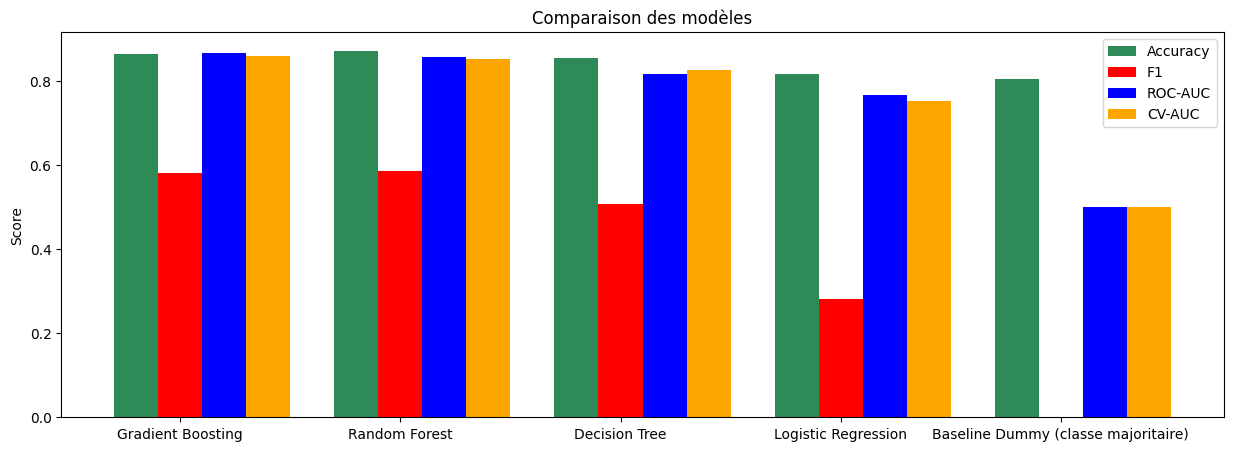

In [ ]:
# graphique comparatif
fig, ax = plt.subplots(figsize=(15, 5))
x = np.arange(len(results_df))
width = 0.2
metrics = ['Accuracy', 'F1', 'ROC-AUC', 'CV-AUC']
colors = ['seagreen', 'red', 'blue', 'orange']

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=colors[i])

ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles')
ax.set_xticks(x + width)
ax.set_xticklabels(results_df['Model'])
ax.legend()
plt.show()

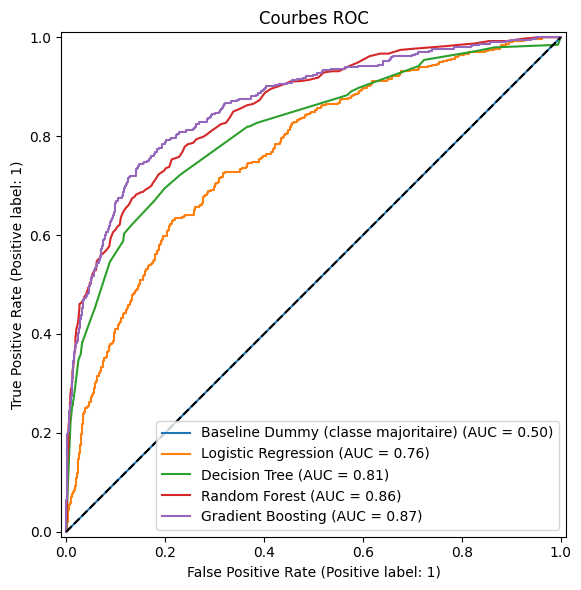

In [40]:
# Courbes ROC superposées
fig, ax = plt.subplots(figsize=(8, 6))
for model_res in results:
    RocCurveDisplay.from_estimator(model_res['object'], X_test, y_test, ax=ax, name=model_res['Model'])

ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_title('Courbes ROC')
plt.tight_layout()
plt.show()

On sait que **plus la courbe est proche du coin supérieur gauche, plus le modèle est performant**. Ainsi, on peut voir que le **Gradient Boosting** et le **Random Forest** ont les meilleures performances, tandis que la **Régression Logistique** est la moins performante, ce qui est cohérent avec les scores ROC-AUC et CV-AUC du tableau récapitulatif précédent.

## **8. Optimisation — RandomizedSearchCV sur Gradient Boosting**

In [41]:
pipeline_Gb = Pipeline([
     ('scaler', StandardScaler()),
     ('model', Gb)]
)

# Grille d'hyperparamètres
param_distributions = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__n_estimators': [100, 150, 200, 250],
    'model__max_depth': [3, 4, 5],
    'model__subsample': [0.8, 1.0],
    'model__max_features': ['sqrt', 'log2'],
}


random_search = RandomizedSearchCV(
    estimator=pipeline_Gb,
    param_distributions=param_distributions,
    n_iter=15,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
)


random_search.fit(X_train, y_train)

# Affichage des résultats
print("\n Meilleurs hyperparamètres :", random_search.best_params_)
print(f"   Meilleur CV-AUC : {random_search.best_score_:.4f}")


 Meilleurs hyperparamètres : {'model__subsample': 0.8, 'model__n_estimators': 150, 'model__max_features': 'sqrt', 'model__max_depth': 5, 'model__learning_rate': 0.05}
   Meilleur CV-AUC : 0.8616


In [42]:
best_pipeline_Gb = random_search.best_estimator_
best_pipeline_Gb

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['credit_score','country','gender',...,'estimated_salary', 'balance_salary_ratio','balance_a_zero']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [43]:
y_pred_best_Gb = best_pipeline_Gb.predict(X_test)
y_proba_best_Gb = best_pipeline_Gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting (optimisé) :")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_best_Gb):.4f}  |  F1 : {f1_score(y_test, y_pred_best_Gb):.4f} |  ROC-AUC : {roc_auc_score(y_test, y_proba_best_Gb):.4f}")

Gradient Boosting (optimisé) :
  Accuracy : 0.8655  |  F1 : 0.5803 |  ROC-AUC : 0.8692


## **9. Interprétabilité — SHAP**

---

In [45]:
! pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 63.1 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 16.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]5/6 [shap]]te]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [46]:
import shap

# Initialisons JS pour les graphiques SHAP
shap.initjs()

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [47]:
# On extrait séparément le modèle et le scaler du pipeline
scaler_final = best_pipeline_Gb.named_steps['scaler']
model_final = best_pipeline_Gb.named_steps['model']

In [48]:
# Initialisons l'explicateur avec notre meilleur modèle
explainer = shap.TreeExplainer(model_final)

### **9.1 SHAP Values pour l'ensemble de test**

In [49]:
# On prépare les données de test normalisées spécifiquement pour SHAP
# On utilise le scaler entraîné à l'intérieur du pipeline
X_test_sc_shap = scaler_final.transform(X_test)

In [50]:
# Calculons les valeurs SHAP pour l'ensemble de test
shap_values = explainer.shap_values(X_test_sc_shap)

### **9.2 Graphiques de synthèse**
Dans cette section, on montrera les caractéristiques les plus importantes. Chaque point sur le graphique est une observation. La position horizontale du point indique l'impact de la caractéristique sur la prédiction du modèle (valeurs SHAP). La couleur indique la valeur de la caractéristique (rouge = élevée, bleu = faible).

Les caractéristiques sont classées par ordre d'importance, les plus impactantes étant en haut.

In [51]:
X_test.info()

<class 'pandas.DataFrame'>
Index: 2000 entries, 6252 to 6929
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   credit_score          2000 non-null   int64  
 1   country               2000 non-null   float64
 2   gender                2000 non-null   float64
 3   age                   2000 non-null   int64  
 4   tenure                2000 non-null   int64  
 5   balance               2000 non-null   float64
 6   products_number       2000 non-null   int64  
 7   credit_card           2000 non-null   int64  
 8   active_member         2000 non-null   int64  
 9   estimated_salary      2000 non-null   float64
 10  balance_salary_ratio  2000 non-null   float64
 11  balance_a_zero        2000 non-null   int64  
dtypes: float64(5), int64(7)
memory usage: 203.1 KB


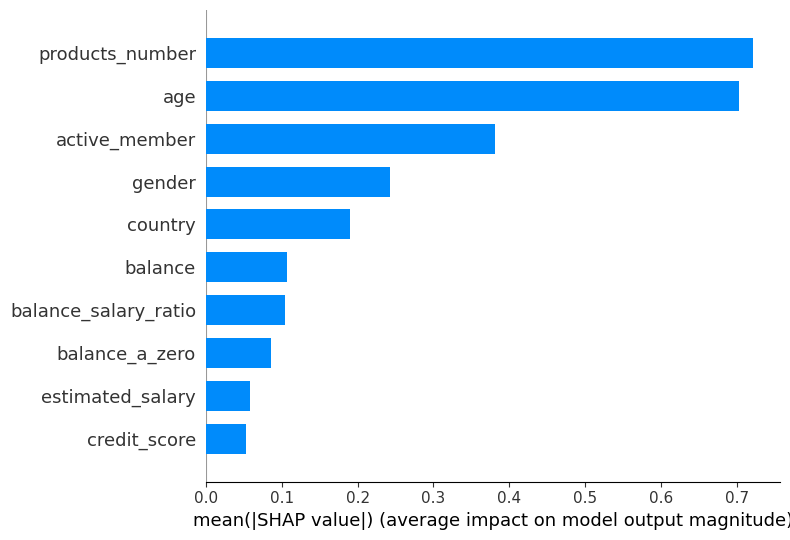

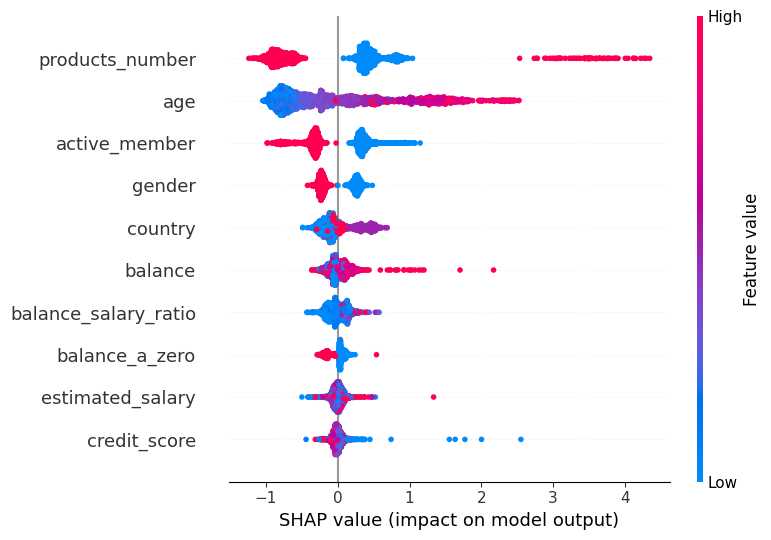

In [52]:
# Affichage
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=10)
shap.summary_plot(shap_values, X_test, max_display=10)

### **9.3 Graphiques de dépendance**
Les graphiques de dépendance montrent comment une seule caractéristique affecte la prédiction du modèle. Chaque point représente une instance du dataset. L'axe x est la valeur de la caractéristique, et l'axe y est la valeur SHAP de cette caractéristique, indiquant son impact sur la prédiction.

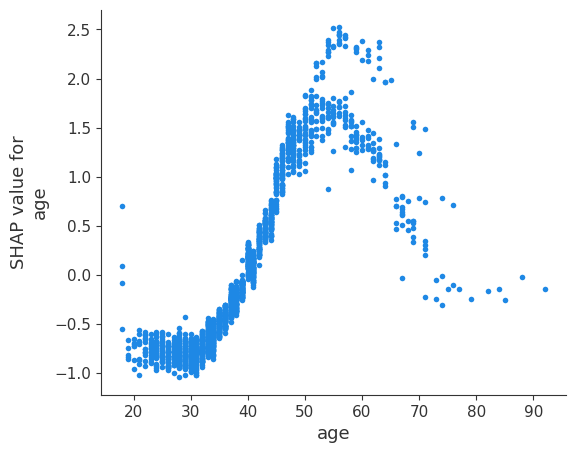

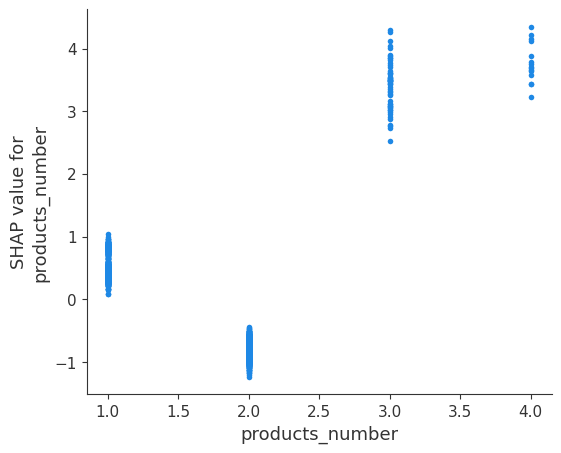

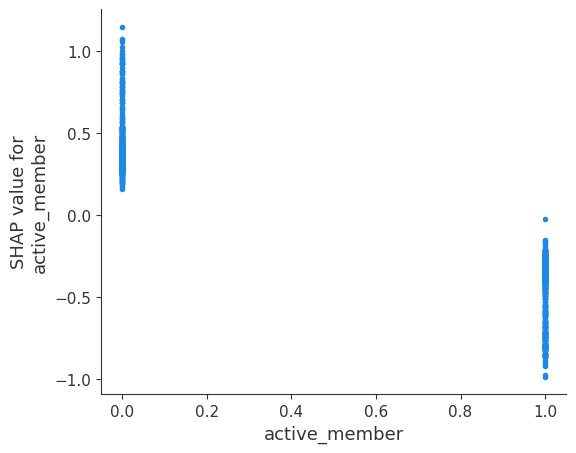

In [53]:
# Pour la caractéristique 'age'
shap.dependence_plot("age", shap_values, X_test, interaction_index=None)

# Pour la caractéristique 'products_number'
shap.dependence_plot("products_number", shap_values, X_test, interaction_index=None)

# Pour la caractéristique 'active_member'
shap.dependence_plot("active_member", shap_values, X_test, interaction_index=None)

## **10 Sauvegarde du modèle**

---

In [56]:
# Séparation terget et features
X_raw = data.drop(columns=['churn'])
y_raw = data['churn']

# Split train/test
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

In [58]:
full_pipeline_Gb = Pipeline([
    ('preprocessing', FeatureEngineering()),
    ('scaler', StandardScaler()),
    ('model', model_final)
])

full_pipeline_Gb.fit(X_train_raw, y_train_raw)

joblib.dump(full_pipeline_Gb, '/workspaces/Bank-Customer-Churn-Prediction/modele/bank_churn_model.joblib')
print("Modèle sérialisé avec succès !!!")

Modèle sérialisé avec succès !!!


### Insights métier clés
- **Le nombre de produits** & **L'âge** sont les prédicteurs les plus fort : les clients plus âgés churnent davantage, ainsi que ceux avec plus de 2 produits.
- **Les membres actifs** sont beaucoup moins susceptibles de partir.
- **L'Allemagne** présente un taux de churn 2× supérieur à la France et l'Espagne.

## **Bibliographie :**
* [0 $\cdot$ Dataset](https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset)
* <a id="ref1"></a>
[1 $\cdot$ CAC – Coût d’Acquisition Client : Définition, Calcul et Optimisation](https://www.custup.com/cac-cout-acquisition-client-definition-calcul/#:~:text=En%20anglais%2C%20le%20Co%C3%BBt%20d,pour%20attirer%20de%20nouveaux%20clients.)
* [2 $\cdot$ Fidélisation client : comment recréer l'attachement ?](https://obendy.com/article/fidelisation-client-comment-recreer-lattachement#:~:text=Les%20donn%C3%A9es%20sont%20%C3%A9loquentes%20%3A%20acqu%C3%A9rir,bouche%2D%C3%A0%2Doreille%20positif.)